# 05E - Feature Selection

Select the most informative features before model training.

In [1]:

import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif

df=pd.read_csv(r"/mnt/data/american_bankruptcy.csv")
df['target']=df['status_label'].map({'alive':0,'failed':1})
drop=['status_label','target']
if 'company_name' in df.columns:
    drop.append('company_name')
X=df.drop(columns=drop)
y=df['target']
num=X.select_dtypes(include='number').columns
X=X[num]
display(X.head())


,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


## Low Variance Filter

In [2]:

selector=VarianceThreshold(threshold=0.0)
selector.fit(X)
kept=X.columns[selector.get_support()]
removed=[c for c in X.columns if c not in kept]
print("Retained:",len(kept))
print("Removed:",removed)


Retained: 19
Removed: []


## Correlation-Based Feature Selection

In [3]:

corr=X.corr().abs()
upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))
drop_corr=[c for c in upper.columns if any(upper[c]>0.90)]
selected_corr=[c for c in X.columns if c not in drop_corr]
print("Dropped due to correlation:",drop_corr)
print("Selected:",len(selected_corr))


Dropped due to correlation: ['X9', 'X10', 'X12', 'X13', 'X14', 'X16', 'X17', 'X18']
Selected: 11


## Mutual Information Scores

,Feature,MI Score
6,X6,0.007039
0,year,0.006294
12,X12,0.004989
15,X15,0.004400
8,X8,0.004055
4,X4,0.003528
11,X11,0.003321
13,X13,0.003069
9,X9,0.003021
16,X16,0.002958


<Axes: title={'center': 'Mutual Information Scores'}, xlabel='Feature'>

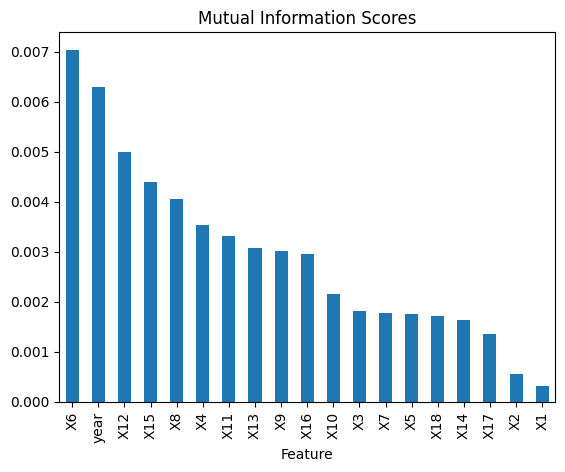

In [4]:

mi=mutual_info_classif(X,y,random_state=42)
mi_df=pd.DataFrame({"Feature":X.columns,"MI Score":mi}).sort_values("MI Score",ascending=False)
display(mi_df)
mi_df.plot.bar(x="Feature",y="MI Score",legend=False,title="Mutual Information Scores")


## SelectKBest

In [5]:

k=min(10,X.shape[1])
skb=SelectKBest(score_func=mutual_info_classif,k=k)
skb.fit(X,y)
selected=X.columns[skb.get_support()]
print("Top features:",list(selected))
display(pd.DataFrame({"Selected Features":selected}))


Top features: ['year', 'X4', 'X6', 'X8', 'X9', 'X11', 'X12', 'X13', 'X15', 'X16']


,Selected Features
0,year
1,X4
2,X6
3,X8
4,X9
5,X11
6,X12
7,X13
8,X15
9,X16


## Export Selected Dataset

In [6]:

X_selected=X[selected]
X_selected.to_csv("selected_features.csv",index=False)
print("Saved: selected_features.csv")
print("Selected shape:",X_selected.shape)


Saved: selected_features.csv
Selected shape: (78682, 10)


## Recommendations

In [7]:

for s in [
"Evaluate feature importance again after training.",
"Use SHAP to validate feature relevance.",
"Feature selection should be performed using training data only."
]:
    print("-",s)


- Evaluate feature importance again after training.
- Use SHAP to validate feature relevance.
- Feature selection should be performed using training data only.
